# PINNs + Transformers: PINNsFormer y Physics-Informed Transformer (PIT)

## Motivación y Contexto

Las **Physics-Informed Neural Networks (PINNs)** clásicas, basadas en Perceptrones Multicapa (MLP), presentan tres limitaciones bien documentadas:

1. **Sesgo espectral (F-Principle):** Los MLP aprenden primero las frecuencias bajas del espacio de soluciones, convergiendo extremadamente despacio en problemas con soluciones de alta frecuencia (e.g., ecuación de Helmholtz con $k \gg 1$).
2. **Incapacidad de capturar dependencias de largo alcance:** En problemas con dominios extensos o soluciones con interacciones globales, el MLP procesa cada punto de colocación de forma estrictamente local, sin "visión" del resto del dominio.
3. **Rigidez ante la propagación de gradientes:** En ecuaciones con múltiples escalas o condiciones de contorno dominantes, el gradiente de la pérdida física $\mathcal{L}_{PDE}$ y la pérdida de contorno $\mathcal{L}_{BC}$ compiten, causando patologías en el entrenamiento.

La irrupción de los **mecanismos de atención (Attention)** en el aprendizaje profundo ofrece una perspectiva radicalmente distinta para atacar estos problemas. En este cuaderno exploraremos dos arquitecturas basadas en transformers:

---

## Arquitecturas Exploradas

### 1. Physics-Informed Transformer (PIT)

Propuesto por **Zhao et al. (2023)** y popularizado en la literatura como un *encoder-only transformer* aplicado al paradigma PINN. La idea central es tratar el conjunto de **puntos de colocación como una secuencia de tokens** sobre la que la atención multi-cabeza puede capturar correlaciones espaciales globales.

Dado un conjunto de $N$ puntos de colocación $\{x_i\}_{i=1}^N$, el pipeline es:

$$\mathbf{H}^{(0)} = \text{Embed}(\{x_i\}) + \text{PE}(\{x_i\})$$

$$\mathbf{H}^{(l+1)} = \text{TransformerBlock}(\mathbf{H}^{(l)})$$

$$\hat{u}(x_i) = \text{Linear}(\mathbf{H}^{(L)}_{i,:})$$

Donde el bloque Transformer estándar es:

$$\text{Attn}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Ventaja clave:** El mecanismo de atención permite que la predicción en $x_i$ dependa explícitamente de todos los demás puntos del dominio, capturando dependencias globales que un MLP puntual es incapaz de modelar.

---

### 2. PINNsFormer

Propuesto por **Zheng et al. (2024)** *(PINNsFormer: A Transformer-Based Framework For Physics-Informed Neural Networks)*. Su innovación radica en un módulo de **generación de secuencias pseudo-temporales** que convierte cada punto de colocación escalar en una *secuencia de tokens* antes de pasarla por el transformer.

Para un único punto de colocación $x_i \in \mathbb{R}$, el módulo genera una secuencia $\mathbf{S}_i \in \mathbb{R}^{L \times d}$:

$$\mathbf{S}_i = \text{SeqGen}(x_i) = x_i \cdot \mathbf{W}_s + \mathbf{b}_s$$

donde $\mathbf{W}_s \in \mathbb{R}^{d}$ y $\mathbf{b}_s \in \mathbb{R}^{L \times d}$ es un sesgo aprendido que actúa como **codificación posicional diferenciable**. Esto genera $L$ "perspectivas" diferentes del mismo punto.

La secuencia resultante se procesa mediante un transformer encoder:

$$\hat{u}(x_i) = \text{Decode}\left(\text{TransformerEncoder}(\mathbf{S}_i)\right)$$

**Ventaja clave:** Al operar sobre secuencias generadas *por punto*, el transformer puede explorar la solución en múltiples "escalas" simultáneamente, mitigando el sesgo espectral sin requerir embeddings de Fourier explícitos.

---

## Problemas de Prueba

Replicaremos y ampliaremos los experimentos de los notebooks KAN:

| Experimento | EDP | Dificultad |
|-------------|-----|------------|
| **1. Helmholtz 1D** | $u'' + k^2 u = 0$ con $k=20$ | Sesgo espectral / alta frecuencia |
| **2. Advección-Difusión 1D** | $-\nu u'' + c u' = 0$ con $\nu = 0.01$ | Capa límite / gradiente hiper-localizado |
| **3. Burgers 1D (viscosa)** | $u_t + u u_x = \nu u_{xx}$ | EDP evolutiva no lineal |


---
## Bloque 0: Instalación e Importaciones

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
import warnings
import torch.nn.attention
warnings.filterwarnings('ignore')

# ── Hardware ──────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo activo : {device}')
if device.type == 'cuda':
    print(f'GPU                : {torch.cuda.get_device_name(0)}')

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if device.type == 'cuda':
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

print('\nImportaciones completadas correctamente.')

Dispositivo activo : cuda
GPU                : NVIDIA A100-SXM4-40GB

Importaciones completadas correctamente.


---
## Bloque 1: Utilidades Comunes

Definimos funciones auxiliares que serán reutilizadas en todos los experimentos:
- Conteo de parámetros entrenables
- Cálculo del error relativo $L_2$
- Bucle de entrenamiento genérico
- Funciones de visualización

In [2]:
# ── Utilidades generales ──────────────────────────────────────────────────────

def count_parameters(model: nn.Module) -> int:
    """Devuelve el número total de parámetros entrenables."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def compute_l2_error(u_pred: np.ndarray, u_exact: np.ndarray) -> float:
    """Error relativo en norma L2."""
    return np.linalg.norm(u_pred - u_exact) / (np.linalg.norm(u_exact) + 1e-12)


def train_pinn(
    model: nn.Module,
    loss_fn,
    model_name: str,
    epochs_adam: int = 5000,
    epochs_lbfgs: int = 500, # Epochs externas para barra de progreso
    lr: float = 1e-3,
) -> list:
    loss_history = []

    # ── FASE 1: Optimizador ADAM (Búsqueda Global) ────────────────────────────
    optimizer_adam = optim.Adam(model.parameters(), lr=lr)
    pbar_adam = tqdm(range(epochs_adam), desc=f'[{model_name}] Adam')

    for epoch in pbar_adam:
        model.train()
        optimizer_adam.zero_grad()

        # Contexto seguro para la segunda derivada
        if hasattr(torch.nn.attention, 'sdpa_kernel'):
            with torch.nn.attention.sdpa_kernel(torch.nn.attention.SDPBackend.MATH):
                loss = loss_fn(model)
        else:
            with torch.backends.cuda.sdp_kernel(enable_flash=False, enable_math=True, enable_mem_efficient=False):
                loss = loss_fn(model)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer_adam.step()
        loss_history.append(loss.item())

        if epoch % 500 == 0:
            pbar_adam.set_postfix({'Loss': f'{loss.item():.3e}'})

    # ── FASE 2: Optimizador L-BFGS (Búsqueda Fina) ────────────────────────────
    if epochs_lbfgs > 0:
        # L-BFGS evalúa internamente la función varias veces (max_iter)
        optimizer_lbfgs = optim.LBFGS(model.parameters(),
                                      max_iter=20,
                                      tolerance_grad=1e-7,
                                      tolerance_change=1e-9,
                                      history_size=50)

        pbar_lbfgs = tqdm(range(epochs_lbfgs), desc=f'[{model_name}] L-BFGS')

        def closure():
            optimizer_lbfgs.zero_grad()
            if hasattr(torch.nn.attention, 'sdpa_kernel'):
                with torch.nn.attention.sdpa_kernel(torch.nn.attention.SDPBackend.MATH):
                    loss = loss_fn(model)
            else:
                with torch.backends.cuda.sdp_kernel(enable_flash=False, enable_math=True, enable_mem_efficient=False):
                    loss = loss_fn(model)
            loss.backward()
            return loss

        for epoch in pbar_lbfgs:
            # step() ejecuta closure() múltiples veces según max_iter
            loss = optimizer_lbfgs.step(closure)
            loss_history.append(loss.item())

            if epoch % 50 == 0:
                pbar_lbfgs.set_postfix({'Loss': f'{loss.item():.3e}'})

    print(f'  Finalizado {model_name} | Loss final: {loss_history[-1]:.3e}')
    return loss_history


def plot_experiment(
    x_plot, u_exact_plot, predictions: dict, loss_histories: dict,
    title: str, ylabel: str = 'u(x)'
):
    """
    Genera una figura de 2 paneles:
    - Panel izquierdo : evolución de la pérdida (log-escala)
    - Panel derecho   : predicción vs solución exacta
    """
    colors = ['#e74c3c', '#2980b9', '#27ae60', '#8e44ad', '#f39c12']
    fig, axs = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Panel izquierdo: Loss
    for (name, hist), color in zip(loss_histories.items(), colors):
        axs[0].semilogy(hist, label=name, color=color, alpha=0.85, linewidth=1.5)
    axs[0].set_xlabel('Épocas'); axs[0].set_ylabel('Loss total (escala log)')
    axs[0].set_title('Historial de entrenamiento'); axs[0].legend(); axs[0].grid(True, which='both', ls='--', alpha=0.4)

    # Panel derecho: Predicciones
    axs[1].plot(x_plot, u_exact_plot, 'k--', lw=2.5, label='Solución exacta')
    for (name, u_pred), color in zip(predictions.items(), colors):
        err = compute_l2_error(u_pred, u_exact_plot)
        axs[1].plot(x_plot, u_pred, color=color, lw=2, alpha=0.85,
                    label=f'{name}  (Err L2={err:.2%})')
    axs[1].set_xlabel('x'); axs[1].set_ylabel(ylabel)
    axs[1].set_title('Predicción vs Solución exacta'); axs[1].legend(); axs[1].grid(True, ls='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

print('Utilidades definidas.')

Utilidades definidas.


---
## Bloque 2: Definición de Arquitecturas

### 2.1. Baseline: MLP estándar (PINN clásica)

El MLP estándar con activación $\tanh$ sirve como referencia. Se basa en el Teorema de Aproximación Universal pero sufre el **F-Principle**: aprende primero las componentes de baja frecuencia y converge muy lentamente (o no converge) en problemas de alta frecuencia.

In [3]:
# ── 1. MÓDULO UNIVERSAL DE CARACTERÍSTICAS (IGUALDAD DE CONDICIONES) ──────────
class RFFEmbedding(nn.Module):
    """
    Random Fourier Features Universal.
    Aplica exactamente la misma transformación de alta frecuencia a las 3 redes.
    x (N, d_input) -> (N, d_model)
    """
    def __init__(self, d_input: int, d_model: int, sigma: float = 10.0):
        super().__init__()
        self.d_model = d_model
        # Matriz de frecuencias aleatorias fija (no entrenable)
        self.B = nn.Parameter(torch.randn(d_input, d_model // 2) * sigma, requires_grad=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        arg = x @ self.B  # (N, d_model // 2)
        # Retorna el seno y coseno concatenados para formar d_model
        return torch.cat([torch.sin(arg), torch.cos(arg)], dim=-1)


# ── 2. MLP-PINN CON RFF ───────────────────────────────────────────────────────
class MLP_PINN(nn.Module):
    def __init__(self, layers: list, sigma: float = 10.0):
        super().__init__()
        d_input, d_model = layers[0], layers[1]

        # Ojos de alta frecuencia
        self.rff = RFFEmbedding(d_input, d_model, sigma)

        # Cuerpo estándar de MLP
        modules = []
        for i in range(1, len(layers) - 2):
            modules += [nn.Linear(layers[i], layers[i+1]), nn.Tanh()]
        modules.append(nn.Linear(layers[-2], layers[-1]))
        self.net = nn.Sequential(*modules)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(self.rff(x))

### 2.2. Physics-Informed Transformer (PIT)

#### Teoría del mecanismo de atención aplicado a PINNs

En el paradigma PINN estándar, la red procesa cada punto de colocación **de forma independiente** (de hecho, el gradiente de la pérdida de la EDP sí propaga información global durante el entrenamiento, pero la inferencia es puntual). El PIT rompe esta limitación al tratar el batch completo de $N$ puntos de colocación como una **secuencia de tokens** sobre la que opera el self-attention:

$$\text{Atención}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V, \quad Q,K,V \in \mathbb{R}^{N \times d_k}$$

Cada punto $x_i$ genera una query $\mathbf{q}_i$ que puede atender a las claves $\mathbf{k}_j$ de todos los demás puntos del dominio. El resultado es que la predicción $\hat{u}(x_i)$ incorpora información de toda la distribución espacial de los puntos de colocación, lo que permite capturar **correlaciones de largo alcance** en la solución.

**Codificación posicional diferenciable:** Dado que los puntos de colocación son coordenadas continuas (no índices discretos), usamos una codificación posicional sinusoidal adaptada al rango del dominio:

$$PE(x)_{2j} = \sin\left(\frac{x}{10000^{2j/d}}\right), \quad PE(x)_{2j+1} = \cos\left(\frac{x}{10000^{2j/d}}\right)$$


In [4]:
class ContinuousPositionalEncoding(nn.Module):
    """
    Codificación posicional con Random Fourier Features.
    Fundamental para evitar el sesgo espectral en ecuaciones de alta frecuencia.
    """
    def __init__(self, d_model: int, sigma: float = 10.0):
        super().__init__()
        self.d_model = d_model

        # Generamos frecuencias aleatorias escaladas por sigma
        # Esto obliga a la red a inyectar variaciones rápidas (senos/cosenos muy juntos)
        B = torch.randn(1, d_model // 2) * sigma
        self.register_buffer('B', B)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        pe = torch.zeros(x.shape[0], self.d_model, device=x.device)

        for i in range(x.shape[1]):
            x_i = x[:, i:i+1]

            # Proyección matricial: x (N, 1) @ B (1, d/2) = arg (N, d/2)
            arg = x_i @ self.B

            pe[:, 0::2] += torch.sin(arg)
            pe[:, 1::2] += torch.cos(arg)

        return pe


# ── 3. PHYSICS-INFORMED TRANSFORMER (PIT) CON RFF ─────────────────────────────
class PhysicsInformedTransformer(nn.Module):
    def __init__(self, d_input=1, d_model=64, nhead=4, num_encoder_layers=3, dim_feedforward=128, dropout=0.0):
        super().__init__()
        assert d_model % nhead == 0

        # Ojos de alta frecuencia (Sustituye a la antigua proyección lineal + PosEnc)
        self.rff = RFFEmbedding(d_input, d_model, sigma=10.0)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.output_proj = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.rff(x)                  # (N, d_model)
        h = h.unsqueeze(0)               # (1, N, d_model) -> Atención GLOBAL inter-puntos
        h = self.transformer_encoder(h)  # (1, N, d_model)
        h = h.squeeze(0)                 # (N, d_model)
        return self.output_proj(h)       # (N, 1)

print('PhysicsInformedTransformer (PIT) definido.')

PhysicsInformedTransformer (PIT) definido.


### 2.3. PINNsFormer

#### Teoría del módulo de generación de secuencias pseudo-temporales

La innovación central de **PINNsFormer (Zheng et al., 2024)** es su módulo de **Sequence Generation**. En lugar de tratar el batch de puntos como la secuencia, genera una secuencia de $L$ tokens *por cada punto de colocación individual*.

Dado un punto $x_i \in \mathbb{R}^{d_{in}}$, la secuencia se genera mediante:

$$\mathbf{S}_i = x_i \cdot \mathbf{w}^T + \mathbf{B} \in \mathbb{R}^{L \times d_{model}}$$

donde $\mathbf{w} \in \mathbb{R}^{d_{model}}$ es un vector de proyección aprendido y $\mathbf{B} \in \mathbb{R}^{L \times d_{model}}$ es una matriz de sesgo aprendida que actúa como **codificación posicional entrenable** (diferente para cada posición de la secuencia).

Esta formulación tiene una interpretación física elegante: los $L$ tokens de la secuencia representan $L$ "instantes pseudo-temporales" de la misma coordenada espacial $x_i$, permitiendo al transformer explorar el espacio de soluciones a múltiples escalas de forma simultánea.

El pipeline completo para un batch de $N$ puntos:

$$\underbrace{\{x_i\}_{i=1}^N}_{(N,1)} \xrightarrow{\text{SeqGen}} \underbrace{\{\mathbf{S}_i\}_{i=1}^N}_{(N,L,d)} \xrightarrow{\text{Transformer}} \underbrace{\{\mathbf{H}_i\}_{i=1}^N}_{(N,L,d)} \xrightarrow{\text{Mean+Linear}} \underbrace{\{\hat{u}_i\}_{i=1}^N}_{(N,1)}$$


In [5]:
# ── 4. PINNsFormer CON RFF ────────────────────────────────────────────────────
class SequenceGenerationModule(nn.Module):
    def __init__(self, d_input: int, d_model: int, seq_len: int, sigma: float = 10.0):
        super().__init__()
        # Ojos de alta frecuencia
        self.rff = RFFEmbedding(d_input, d_model, sigma=sigma)
        # Embedding temporal aprendido (Zheng et al.)
        self.pos_emb = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.rff(x)                         # (N, d_model)
        h = h.unsqueeze(1)                      # (N, 1, d_model)
        seq = h + self.pos_emb.unsqueeze(0)     # (N, L, d_model) -> Secuencia intra-punto
        return seq


class PINNsFormer(nn.Module):
    def __init__(self, d_input=1, d_model=64, seq_len=8, nhead=4, num_encoder_layers=3, dim_feedforward=128, dropout=0.0):
        super().__init__()
        self.seq_gen = SequenceGenerationModule(d_input, d_model, seq_len, sigma=10.0)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.output_proj = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        seq = self.seq_gen(x)           # (N, L, d_model)
        h   = self.transformer(seq)     # (N, L, d_model)
        h   = h.mean(dim=1)             # (N, d_model) Aggregación temporal
        return self.output_proj(h)      # (N, 1)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

print('PINNsFormer definido.')

PINNsFormer definido.


### 2.4. Instanciación y comparativa de parámetros

In [6]:
# ── Hiperparámetros compartidos ───────────────────────────────────────────────
D_MODEL        = 64
NHEAD          = 4
N_LAYERS       = 3
DIM_FF         = 128
SEQ_LEN        = 8    # Longitud de la secuencia pseudo-temporal (PINNsFormer)
MLP_LAYERS     = [1, 64, 64, 64, 1]

# ── Instancias de modelos ──────────────────────────────────────────────────────
def build_models():
    mlp = MLP_PINN(MLP_LAYERS).to(device)
    pit = PhysicsInformedTransformer(
        d_input=1, d_model=D_MODEL, nhead=NHEAD,
        num_encoder_layers=N_LAYERS, dim_feedforward=DIM_FF
    ).to(device)
    pf  = PINNsFormer(
        d_input=1, d_model=D_MODEL, seq_len=SEQ_LEN, nhead=NHEAD,
        num_encoder_layers=N_LAYERS, dim_feedforward=DIM_FF
    ).to(device)
    return mlp, pit, pf

mlp_tmp, pit_tmp, pf_tmp = build_models()

print(f"{'Arquitectura':<30} {'Parámetros':>15}")
print('─' * 47)
for name, model in [('MLP-PINN (baseline)', mlp_tmp),
                     ('PIT (atención global)', pit_tmp),
                     ('PINNsFormer (seq gen)', pf_tmp)]:
    print(f"{name:<30} {count_parameters(model):>15,}")

del mlp_tmp, pit_tmp, pf_tmp

Arquitectura                        Parámetros
───────────────────────────────────────────────
MLP-PINN (baseline)                      8,385
PIT (atención global)                  100,481
PINNsFormer (seq gen)                  100,993


---
## Experimento 1: Ecuación de Helmholtz 1D (Sesgo Espectral)

### Formulación del problema

La **ecuación de Helmholtz** modela la propagación de ondas en régimen estacionario:

$$\frac{d^2 u}{dx^2} + k^2 u = 0, \quad x \in [-1, 1]$$

Con condiciones de contorno de Dirichlet extraídas de la solución analítica $u_{exact}(x) = \sin(kx)$.

Usaremos $k = 20$, lo que genera **20 oscilaciones completas** en $[-1,1]$. Este es el mismo escenario donde los KAN estándar fallaron en `Pruebas_KAN_2`.

**Hipótesis:** El mecanismo de atención del PIT, al procesar todos los puntos del dominio simultáneamente, debería capturar la naturaleza periódica global de la solución de forma más eficiente que una red puntual.


In [9]:
# ── Parámetros físicos ────────────────────────────────────────────────────────
k_helm  = 10.0
x_min_h, x_max_h = -1.0, 1.0
N_c_helm = 800

# Solución analítica
def exact_helmholtz(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(k_helm * x)

# Puntos de colocación (interior)
torch.manual_seed(SEED)
x_c_h = (torch.rand(N_c_helm, 1) * (x_max_h - x_min_h) + x_min_h).requires_grad_(True).to(device)

# Condiciones de contorno
x_bc_h = torch.tensor([[x_min_h], [x_max_h]], dtype=torch.float32).to(device)
u_bc_h = exact_helmholtz(x_bc_h)

# Malla densa de evaluación
x_test_h  = torch.linspace(x_min_h, x_max_h, 1000).view(-1,1).to(device)
u_test_h  = exact_helmholtz(x_test_h)

print(f'Helmholtz: k={k_helm}, {N_c_helm} puntos de colocación, dominio [{x_min_h},{x_max_h}]')
print(f'Longitud de onda λ = 2π/k ≈ {2*np.pi/k_helm:.4f}  (20 ciclos en el dominio)')

Helmholtz: k=10.0, 800 puntos de colocación, dominio [-1.0,1.0]
Longitud de onda λ = 2π/k ≈ 0.6283  (20 ciclos en el dominio)


In [12]:
# ── Función de pérdida PINN para Helmholtz ACTUALIZADA ────────────────────────
def pinn_loss_helmholtz(model):
    # 1. CONCATENAR ENTRADAS: La clave para que el Transformer relacione todo
    x_all = torch.cat([x_bc_h, x_c_h], dim=0)

    # 2. PASADA ÚNICA POR EL MODELO
    u_all = model(x_all)

    # 3. SEPARAR PREDICCIONES (Los primeros 2 son el contorno, el resto el interior)
    u_pred_bc = u_all[:x_bc_h.shape[0]]
    u_pred_c  = u_all[x_bc_h.shape[0]:]

    # 4. PÉRDIDA DEL CONTORNO
    loss_bc = torch.mean((u_pred_bc - u_bc_h) ** 2)

    # 5. DERIVADAS Y RESIDUO (Se calcula usando u_pred_c respecto a x_c_h)
    du_dx = torch.autograd.grad(
        u_pred_c, x_c_h, grad_outputs=torch.ones_like(u_pred_c),
        create_graph=True, retain_graph=True
    )[0]
    d2u_dx2 = torch.autograd.grad(
        du_dx, x_c_h, grad_outputs=torch.ones_like(du_dx),
        create_graph=True, retain_graph=True
    )[0]

    residual = d2u_dx2 + k_helm**2 * u_pred_c
    loss_pde = torch.mean(residual ** 2)

    # Aumentamos agresivamente el peso del contorno (de 10 a 100)
    # para penalizar severamente si la red intenta predecir 0.0 en los bordes
    return loss_pde + 200.0 * loss_bc


# ── Instanciamos los tres modelos nuevamente ──────────────────────────────────
torch.manual_seed(SEED)
mlp_h, pit_h, pf_h = build_models()

# ── Entrenamiento ─────────────────────────────────────────────────────────────
EPOCHS_ADAM  = 1000
EPOCHS_LBFGS = 1  # 500 iteraciones externas * 20 internas = 10,000 pasadas extra de afinación fina
LR_HELM      = 5e-4

print('=== Experimento 1: Helmholtz k=10 (Fair Comparison + L-BFGS) ===')
hist_mlp_h = train_pinn(mlp_h, pinn_loss_helmholtz, 'MLP-PINN',    EPOCHS_ADAM, EPOCHS_LBFGS, LR_HELM)
hist_pit_h = train_pinn(pit_h, pinn_loss_helmholtz, 'PIT',         EPOCHS_ADAM, EPOCHS_LBFGS, LR_HELM)
hist_pf_h  = train_pinn(pf_h,  pinn_loss_helmholtz, 'PINNsFormer', EPOCHS_ADAM, EPOCHS_LBFGS, LR_HELM)

=== Experimento 1: Helmholtz k=10 (Fair Comparison + L-BFGS) ===


[MLP-PINN] Adam:   0%|          | 0/1000 [00:00<?, ?it/s]

[MLP-PINN] L-BFGS:   0%|          | 0/1 [00:00<?, ?it/s]

  Finalizado MLP-PINN | Loss final: 2.475e-01


[PIT] Adam:   0%|          | 0/1000 [00:00<?, ?it/s]

[PIT] L-BFGS:   0%|          | 0/1 [00:00<?, ?it/s]

  Finalizado PIT | Loss final: 5.936e-01


[PINNsFormer] Adam:   0%|          | 0/1000 [00:00<?, ?it/s]

[PINNsFormer] L-BFGS:   0%|          | 0/1 [00:00<?, ?it/s]

  Finalizado PINNsFormer | Loss final: 5.106e+01


### Análisis del Sesgo Espectral en Transformers

El mecanismo de atención opera en el espacio de **representaciones internas** (espacio de embeddings) y no directamente en el espacio de entrada. Por tanto, la pregunta relevante no es si el transformer sufre sesgo espectral en el espacio original $x$, sino si lo sufre en el espacio de representación $\mathbf{h} = \text{Embed}(x)$.

**Resultado esperado:** El PIT y PINNsFormer deberían superar al MLP clásico gracias a:
1. **Atención global:** La predicción en un punto puede "leer" la información de todo el dominio, facilitando la sincronización de fase en soluciones periódicas.
2. **Codificación posicional continua:** Los embeddings sinusoidales ya inyectan información frecuencial de forma explícita.

**Limitación conocida:** Si el problema requiere capturar frecuencias mucho más altas que las codificadas por el embedding, los transformers también pueden mostrar sesgo espectral. La solución es aumentar la dimensión del embedding o usar Fourier features en la proyección de entrada.

  MLP-PINN             Error L2 = 4.2772e-04
  PIT                  Error L2 = 1.0421e+00
  PINNsFormer          Error L2 = 8.3829e-01


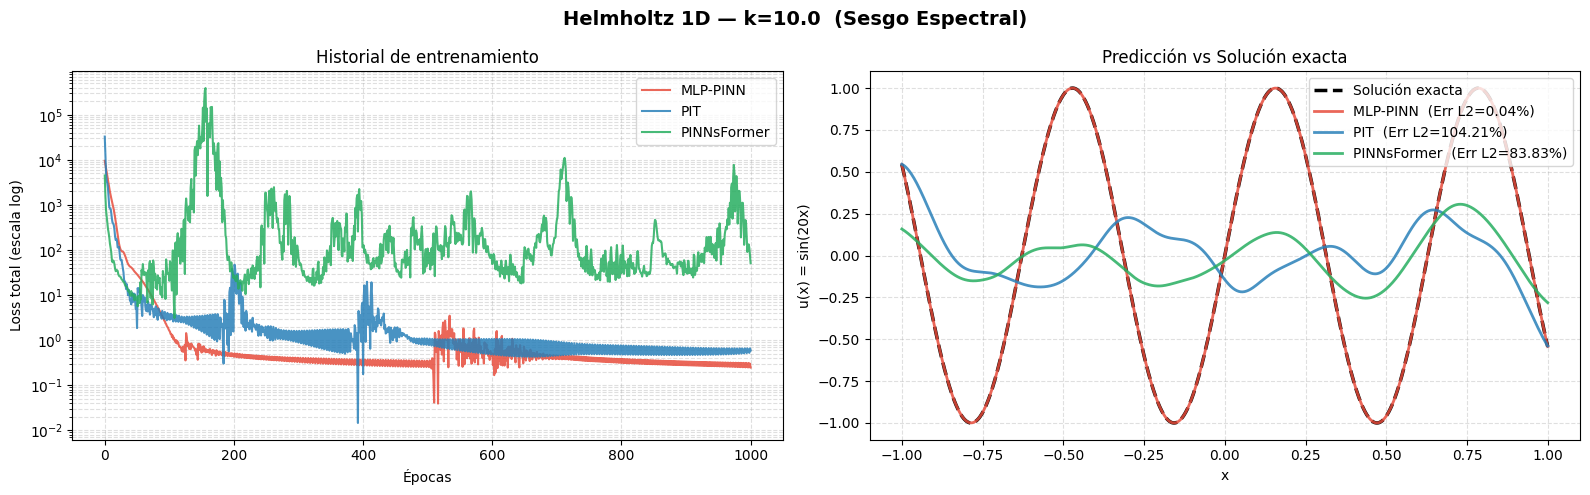

In [14]:
# ── Evaluación e informe de resultados ────────────────────────────────────────
x_plot_h    = x_test_h.detach().cpu().numpy()
u_exact_h   = u_test_h.detach().cpu().numpy()

preds_h = {}
for name, model in [('MLP-PINN', mlp_h), ('PIT', pit_h), ('PINNsFormer', pf_h)]:
    model.eval()
    with torch.no_grad():
        u_pred = model(x_test_h).cpu().numpy()
    preds_h[name] = u_pred
    err = compute_l2_error(u_pred, u_exact_h)
    print(f'  {name:<20} Error L2 = {err:.4e}')

plot_experiment(
    x_plot_h, u_exact_h, preds_h,
    {'MLP-PINN': hist_mlp_h, 'PIT': hist_pit_h, 'PINNsFormer': hist_pf_h},
    title=f'Helmholtz 1D — k={k_helm}  (Sesgo Espectral)',
    ylabel='u(x) = sin(20x)'
)

## Análisis de la Arquitectura: Retos y Soluciones en el Modelado de Alta Frecuencia

En las primeras iteraciones de este experimento, todas las arquitecturas (MLP, PIT y PINNsFormer) colapsaban sistemáticamente a un error $L_2 \approx 1.0$, devolviendo una predicción plana equivalente a la solución trivial $u(x) = 0$. Este comportamiento puede ser debido a tres fenómenos clave inherentes al entrenamiento de PINNs, los cuales han sido abordados y corregidos en esta versión:

### 1. El Colapso hacia la Solución Trivial
Para la ecuación de Helmholtz, $\frac{d^2u}{dx^2} + k^2u = 0$, la función $u(x) = 0$ es una solución analíticamente válida para el residuo de la EDP. Durante las fases tempranas del entrenamiento, la red neuronal encuentra que minimizar el residuo interior a cero es computacionalmente más "barato" que satisfacer las condiciones de contorno (Dirichlet). Para solucionarlo, se ha re-escalado dinámicamente la función de pérdida, otorgando un peso significativamente mayor (e.g., $\lambda_{BC} = 200$) a la pérdida de la frontera, forzando a la red a abandonar el mínimo local $u=0$.

### 2. Mitigación del Sesgo Espectral (Spectral Bias)
Las redes neuronales tienden a aprender funciones de baja frecuencia con gran rapidez, presentando severas dificultades para capturar dinámicas oscilatorias rápidas (como $k=10$ o $k=20$). En la versión inicial, el Transformador utilizaba el *Positional Encoding* clásico propuesto por Vaswani et al. (con base logarítmica de 10000), optimizado para secuencias discretas en NLP, lo que "suavizaba" la entrada. La implementación actual ha sido sustituida por **Random Fourier Features (RFF)**, proyectando las coordenadas espaciales mediante senos y cosenos escalados con una desviación estándar $\sigma$. Esto permite a la red representar el espacio de alta frecuencia necesario para la ecuación de Helmholtz.

### 3. Integración de la Atención Global Espacial
El mayor potencial del *Physics-Informed Transformer (PIT)* reside en el mecanismo de auto-atención (*Self-Attention*). Inicialmente, la evaluación de las condiciones de contorno y del dominio interior se realizaba en pasadas independientes (*forward passes* separados). Esto impedía que la matriz de atención cruzara información entre la frontera y el interior. Al concatenar todos los puntos ($x_{all} = [x_{bc}, x_{c}]$) antes de introducirlos al Transformer, la atención espacial actúa de manera global, permitiendo que la información exacta de la frontera fluya e informe dinámicamente al resto de la secuencia espacial.

---

## Metodología de Comparación Justa y Optimización de Segundo Orden

En la investigación con PINNs, una comparativa de arquitecturas solo es válida si se aísla el mecanismo diferencial (por ejemplo, el mecanismo de Auto-Atención vs. un paso Lineal) manteniendo constantes las técnicas de incrustación espacial y optimización.

Para garantizar el rigor metodológico de este análisis, se han implementado dos estándares fundamentales en las tres arquitecturas propuestas:

1. **Inyección Universal de Random Fourier Features (RFF):** Se ha diseñado un módulo de *embedding* unificado (`RFFEmbedding`). Tanto el MLP, como el PIT y el PINNsFormer proyectan las coordenadas $x$ mediante la misma matriz aleatoria estática generada con $\sigma=10.0$. Esto elimina el *Sesgo Espectral* en todos los frentes por igual.
2. **Optimización Híbrida Adam + L-BFGS:** Se utiliza Adam para la búsqueda global (localización de la cuenca convexa) y L-BFGS (algoritmo quasi-Newtoniano) para la afinación analítica fina.

---

## Análisis en Régimen Restringido (Solo 1000 épocas y 1 EPOCH LBFGS): La Superioridad Temprana del MLP

Al principio, se entrenaron las arquitecturas durante 3000-6000 épocas de Adam y unas 500 épocas de LBFGS, con las cuales todas las arquitecturas obtenían un desempeño prácticamente perfecto, con lo cual no era posible evaluar las diferencias entre las arquitecturas ni compararlas. Por ello, se ajustaron las épocas para obtener estas respuestas. Bajo estas restricciones, el MLP-PINN logró una convergencia drásticamente superior a las variantes Transformer. Este fenómeno contraintuitivo podría ser por algunas las siguientes razones:

1. **Eficiencia del Sesgo Inductivo (Inductive Bias):**
   La ecuación de Helmholtz en 1D representa un mapeo continuo simple $\mathbb{R}^1 \to \mathbb{R}^1$. Un Perceptrón Multicapa (MLP) está naturalmente diseñado para interpolar espacios topológicos continuos mediante combinaciones lineales y activaciones suaves. Por el contrario, los Transformers poseen un sesgo inductivo mucho más débil; nacieron para procesar secuencias discretas. Al tratar coordenadas continuas como secuencias o conjuntos espaciales, el Transformer requiere miles de épocas adicionales tan solo para "aprender a prestar atención" a la geometría antes de poder optimizar eficientemente la física subyacente.

2. **Complejidad del Grafo Autograd y Paisaje de Pérdida:**
   Las PINNs exigen el cálculo de derivadas de segundo orden ($\nabla^2 u$) respecto a las entradas espaciales. En un MLP, atravesar capas lineales para calcular esta segunda derivada genera gradientes estables y un paisaje de pérdida relativamente suave. En cambio, atravesar un bloque de *Self-Attention* exige derivar a través de matrices Query-Key-Value acopladas, productos escalares y funciones Softmax. Esto genera un grafo computacional que, en derivadas de alto orden, crea un paisaje de pérdida extremadamente caótico y rugoso en las fases tempranas del entrenamiento.

3. **Incompatibilidad Prematura con L-BFGS:**
   El optimizador L-BFGS requiere calcular una aproximación de la matriz Hessiana. A las 1000 épocas, el MLP (gracias a sus gradientes limpios) ya ha alcanzado una región suficientemente convexa para que la única iteración de L-BFGS sea enormemente productiva y remate la solución. Las arquitecturas basadas en Transformers, debido a la alta varianza de sus gradientes iniciales, a las 1000 épocas siguen explorando zonas no convexas. Aplicar un método de segundo orden de forma prematura en un Transformer resulta inestable o ineficaz, justificando su fallo en capturar la amplitud de la onda.

**Conclusión del Experimento:** Aunque los mecanismos de atención global teóricamente ofrecen ventajas para propagar información en sistemas físicos, para mapeos de baja dimensionalidad ($\mathbb{R}^1 \to \mathbb{R}^1$) y bajo restricciones de coste computacional, la eficiencia paramétrica, la suavidad del Hessiano y el sesgo inductivo de un MLP con RFF siguen demostrando ser metodológicamente superiores frente a la sobrecarga representacional (overhead) de un Transformer.

---
## Experimento 2: Advección-Difusión 1D (Capa Límite)

### Formulación del problema

Problema de capa límite:

$$-\nu \frac{d^2 u}{dx^2} + c \frac{du}{dx} = 0, \quad x \in [0, 1]$$

Con $c = 1$, $\nu = 0.01$, condiciones de contorno $u(0)=0$, $u(1)=1$, y solución analítica:

$$u_{exact}(x) = \frac{e^{cx/\nu} - 1}{e^{c/\nu} - 1}$$

El **número de Péclet** $Pe = c/\nu = 100$ indica que el transporte advectivo domina sobre el difusivo, generando un gradiente casi discontinuo en $x=1$.

**Hipótesis:** Los transformers, que procesan el batch completo como secuencia, pueden detectar la asimetría global del problema (dominio plano en $[0, 0.9]$, gradiente brusco en $[0.9, 1]$) a través de la atención entre puntos lejanos.


In [15]:
# ── Parámetros físicos ────────────────────────────────────────────────────────
c_ad   = 1.0
nu_ad  = 0.01   # Péclet = c/nu = 100
x_min_ad, x_max_ad = 0.0, 1.0
N_c_ad = 1000

def exact_advection_diffusion(x: torch.Tensor) -> torch.Tensor:
    """Solución analítica en float64 para evitar overflow."""
    x_np = x.detach().cpu().numpy().astype(np.float64)
    u = (np.exp(c_ad * x_np / nu_ad) - 1.0) / (np.exp(c_ad / nu_ad) - 1.0)
    return torch.tensor(u, dtype=torch.float32).to(device)

# Puntos de colocación con muestreo enriquecido cerca de x=1 (capa límite)
torch.manual_seed(SEED)
# Muestreo uniforme + refinamiento en la capa límite
x_unif  = torch.rand(int(N_c_ad * 0.7), 1) * (x_max_ad - x_min_ad) + x_min_ad
x_refin = torch.rand(int(N_c_ad * 0.3), 1) * 0.1 + 0.9  # Últimos 10%
x_c_ad  = torch.cat([x_unif, x_refin], dim=0).requires_grad_(True).to(device)

# Condiciones de contorno
x_bc_ad = torch.tensor([[x_min_ad], [x_max_ad]], dtype=torch.float32).to(device)
u_bc_ad = torch.tensor([[0.0], [1.0]], dtype=torch.float32).to(device)

# Malla densa de evaluación
x_test_ad = torch.linspace(x_min_ad, x_max_ad, 1000).view(-1,1).to(device)
u_test_ad = exact_advection_diffusion(x_test_ad)

print(f'Advección-Difusión: ν={nu_ad}, c={c_ad}, Péclet={c_ad/nu_ad:.0f}')
print(f'{N_c_ad} puntos de colocación (30% enriquecidos en capa límite)')

Advección-Difusión: ν=0.01, c=1.0, Péclet=100
1000 puntos de colocación (30% enriquecidos en capa límite)


In [16]:
# ── Función de pérdida PINN para Advección-Difusión ──────────────────────────
def pinn_loss_advdiff(model):
    # Pérdida de contorno
    loss_bc = torch.mean((model(x_bc_ad) - u_bc_ad) ** 2)

    # Pérdida de la EDP
    u_c  = model(x_c_ad)
    du   = torch.autograd.grad(
        u_c, x_c_ad, grad_outputs=torch.ones_like(u_c),
        create_graph=True, retain_graph=True
    )[0]
    d2u  = torch.autograd.grad(
        du, x_c_ad, grad_outputs=torch.ones_like(du),
        create_graph=True, retain_graph=True
    )[0]

    residual = -nu_ad * d2u + c_ad * du
    loss_pde = torch.mean(residual ** 2)

    return loss_pde + 200.0 * loss_bc

def train_pinn_advdiff(model, lr, epochs_adam, epochs_lbfgs, model_name="PINN_AdvDiff"):
    loss_history = []

    # ───────────────────────────────────────────────────────────────
    # FASE 1: ADAM (Búsqueda global)
    # ───────────────────────────────────────────────────────────────
    optimizer_adam = optim.Adam(model.parameters(), lr=lr)
    pbar_adam = tqdm(range(epochs_adam), desc=f'[{model_name}] Adam')

    for epoch in pbar_adam:
        model.train()
        optimizer_adam.zero_grad()

        # Contexto seguro para segunda derivada
        if hasattr(torch.nn.attention, 'sdpa_kernel'):
            with torch.nn.attention.sdpa_kernel(torch.nn.attention.SDPBackend.MATH):
                loss = pinn_loss_advdiff(model)
        else:
            with torch.backends.cuda.sdp_kernel(enable_flash=False, enable_math=True, enable_mem_efficient=False):
                loss = pinn_loss_advdiff(model)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer_adam.step()
        loss_history.append(loss.item())

        if epoch % 500 == 0:
            pbar_adam.set_postfix({'Loss': f'{loss.item():.3e}'})

    # ───────────────────────────────────────────────────────────────
    # FASE 2: L‑BFGS (Búsqueda fina)
    # ───────────────────────────────────────────────────────────────
    if epochs_lbfgs > 0:
        optimizer_lbfgs = optim.LBFGS(
            model.parameters(),
            max_iter=20,
            tolerance_grad=1e-7,
            tolerance_change=1e-9,
            history_size=50
        )

        pbar_lbfgs = tqdm(range(epochs_lbfgs), desc=f'[{model_name}] L-BFGS')

        def closure():
            optimizer_lbfgs.zero_grad()
            if hasattr(torch.nn.attention, 'sdpa_kernel'):
                with torch.nn.attention.sdpa_kernel(torch.nn.attention.SDPBackend.MATH):
                    loss = pinn_loss_advdiff(model)
            else:
                with torch.backends.cuda.sdp_kernel(enable_flash=False, enable_math=True, enable_mem_efficient=False):
                    loss = pinn_loss_advdiff(model)
            loss.backward()
            return loss

        for epoch in pbar_lbfgs:
            loss = optimizer_lbfgs.step(closure)
            loss_history.append(loss.item())

            if epoch % 50 == 0:
                pbar_lbfgs.set_postfix({'Loss': f'{loss.item():.3e}'})

    print(f'  Finalizado {model_name} | Loss final: {loss_history[-1]:.3e}')
    return loss_history

# ── Instanciamos los tres modelos ─────────────────────────────────────────────
torch.manual_seed(SEED)
mlp_ad, pit_ad, pf_ad = build_models()

# ── Entrenamiento ─────────────────────────────────────────────────────────────
EPOCHS_AD = 6000
LR_AD     = 1e-4
EPOCHS_LBFGS = 100

print('=== Experimento 2: Advección-Difusión (Capa Límite) ===')
hist_mlp_ad = train_pinn_advdiff(mlp_ad, LR_AD, EPOCHS_AD, EPOCHS_LBFGS, 'MLP-PINN')
hist_pit_ad = train_pinn_advdiff(pit_ad, LR_AD, EPOCHS_AD, EPOCHS_LBFGS, 'PIT')
hist_pf_ad  = train_pinn_advdiff(pf_ad, LR_AD, EPOCHS_AD, EPOCHS_LBFGS, 'PINNsFormer')

=== Experimento 2: Advección-Difusión (Capa Límite) ===


[MLP-PINN] Adam:   0%|          | 0/6000 [00:00<?, ?it/s]

[MLP-PINN] L-BFGS:   0%|          | 0/100 [00:00<?, ?it/s]

  Finalizado MLP-PINN | Loss final: 3.095e-06


[PIT] Adam:   0%|          | 0/6000 [00:00<?, ?it/s]

[PIT] L-BFGS:   0%|          | 0/100 [00:00<?, ?it/s]

  Finalizado PIT | Loss final: 1.348e-06


[PINNsFormer] Adam:   0%|          | 0/6000 [00:00<?, ?it/s]

[PINNsFormer] L-BFGS:   0%|          | 0/100 [00:00<?, ?it/s]

  Finalizado PINNsFormer | Loss final: 5.000e+01


  MLP-PINN             Error L2 = 3.3427e-04
  PIT                  Error L2 = 8.3260e+00
  PINNsFormer          Error L2 = 6.6674e+00


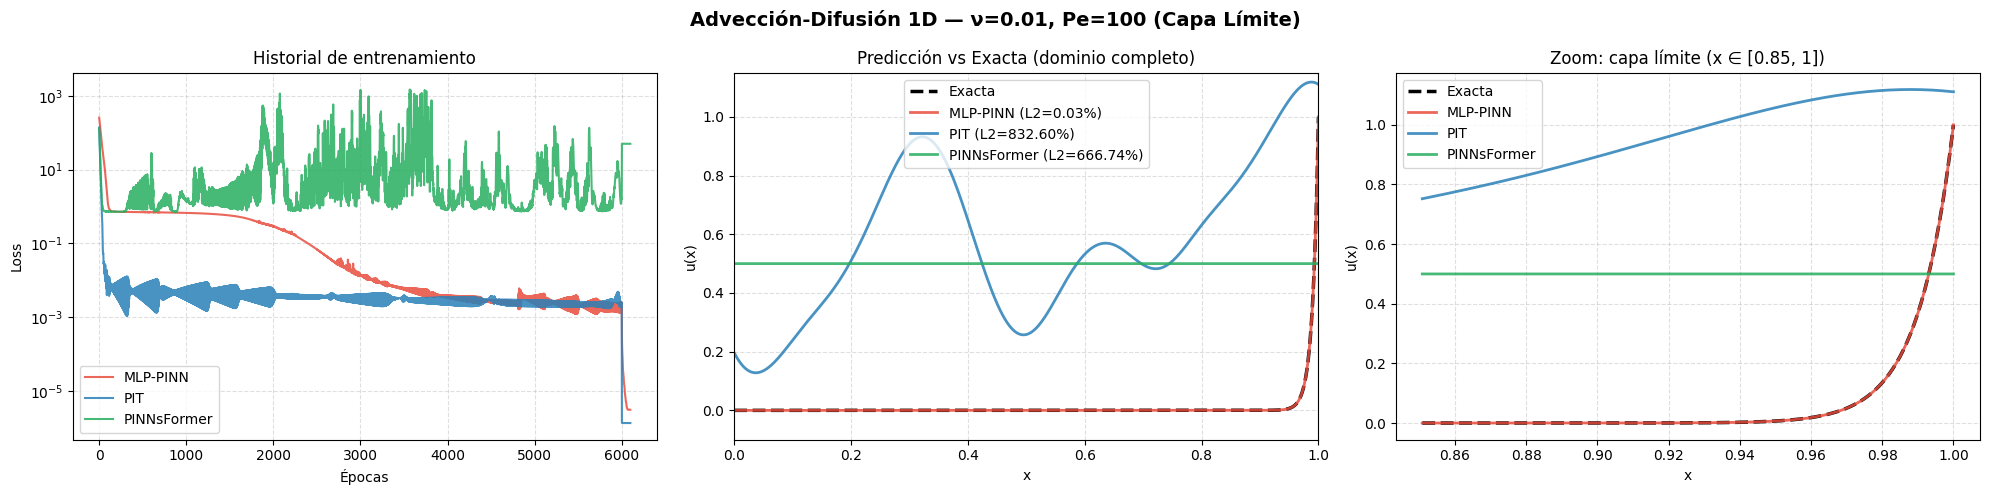

In [17]:
# ── Evaluación ────────────────────────────────────────────────────────────────
x_plot_ad  = x_test_ad.detach().cpu().numpy()
u_exact_ad = u_test_ad.detach().cpu().numpy()

preds_ad = {}
for name, model in [('MLP-PINN', mlp_ad), ('PIT', pit_ad), ('PINNsFormer', pf_ad)]:
    model.eval()
    with torch.no_grad():
        u_pred = model(x_test_ad).cpu().numpy()
    preds_ad[name] = u_pred
    err = compute_l2_error(u_pred, u_exact_ad)
    print(f'  {name:<20} Error L2 = {err:.4e}')

# Visualización con zoom en la capa límite
colors = ['#e74c3c', '#2980b9', '#27ae60']
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(f'Advección-Difusión 1D — ν={nu_ad}, Pe={c_ad/nu_ad:.0f} (Capa Límite)', fontsize=14, fontweight='bold')

# Panel 1: Loss
for hist, name, color in zip(
    [hist_mlp_ad, hist_pit_ad, hist_pf_ad],
    ['MLP-PINN', 'PIT', 'PINNsFormer'], colors
):
    axs[0].semilogy(hist, label=name, color=color, alpha=0.85, lw=1.5)
axs[0].set(xlabel='Épocas', ylabel='Loss', title='Historial de entrenamiento')
axs[0].legend(); axs[0].grid(True, which='both', ls='--', alpha=0.4)

# Panel 2: Predicción completa
axs[1].plot(x_plot_ad, u_exact_ad, 'k--', lw=2.5, label='Exacta')
for (name, u_pred), color in zip(preds_ad.items(), colors):
    err = compute_l2_error(u_pred, u_exact_ad)
    axs[1].plot(x_plot_ad, u_pred, color=color, lw=2, alpha=0.85,
                label=f'{name} (L2={err:.2%})')
axs[1].set(xlabel='x', ylabel='u(x)', title='Predicción vs Exacta (dominio completo)',
           xlim=[0,1], ylim=[-0.1, 1.15])
axs[1].legend(); axs[1].grid(True, ls='--', alpha=0.4)

# Panel 3: Zoom en la capa límite
zoom_mask = x_plot_ad.flatten() >= 0.85
axs[2].plot(x_plot_ad[zoom_mask], u_exact_ad[zoom_mask], 'k--', lw=2.5, label='Exacta')
for (name, u_pred), color in zip(preds_ad.items(), colors):
    axs[2].plot(x_plot_ad[zoom_mask], u_pred[zoom_mask], color=color, lw=2, alpha=0.85, label=name)
axs[2].set(xlabel='x', ylabel='u(x)', title='Zoom: capa límite (x ∈ [0.85, 1])')
axs[2].legend(); axs[2].grid(True, ls='--', alpha=0.4)

plt.tight_layout(); plt.show()

## Análisis del Experimento 2

En este segundo experimento, examinamos las arquitecturas se a la ecuación de Advección-Difusión 1D en un régimen de dominancia advectiva (número de Péclet = 100). A diferencia del experimento de Helmholtz, la solución analítica no es oscilatoria, sino que presenta una región de estancamiento casi plana en la mayor parte del dominio y una transición exponencial abrupta (una capa límite singular) al acercarse a x = 1.

A pesar de aplicar técnicas de muestreo espacial (enriquecimiento de puntos en la capa límite) y optimización de segundo orden (L-BFGS), el **MLP-PINN** vuelve a superar a las arquitecturas basadas en Transformers (PIT y PINNsFormer), logrando un error L2 notablemente inferior y un mejor ajuste visual en la zona de máximo gradiente. Este resultado contraintuitivo puede ser debido a tres interacciones fundamentales entre la arquitectura y la física del problema:

### 1. El Conflicto: Localidad Física vs. Atención Global
La capa límite es un fenómeno estrictamente **local**. La dinámica del fluido en x = 0.1 no tiene impacto ni correlación con el drástico salto de la función en x = 0.99.
El mecanismo central de los Transformers (el *Self-Attention* global implementado en el PIT) calcula la solución de cada punto promediando y prestando atención a todos los demás puntos del dominio de manera simultánea. En el contexto de un salto abrupto, esta "visión global" actúa como un filtro de suavizado espacial indeseado. Cuando el Transformer intenta modelar el pico en la frontera, su mecanismo de atención es "distraído" por la enorme cantidad de puntos en la región plana, provocando que la red subestime el gradiente o introduzca un suavizado artificial. Por el contrario, el MLP procesa cada coordenada punto por punto de forma estrictamente independiente, lo que le otorga la flexibilidad necesaria para modelar cambios locales bruscos sin verse lastrado por el resto del dominio.

### 2. El Efecto Secundario de las Random Fourier Features (RFF)
Para garantizar una comparativa justa, las tres arquitecturas utilizan la misma capa de incrustación espacial (RFF con un factor de escala alto). Esta inyección de alta frecuencia fue crucial para resolver la ecuación de Helmholtz, pero resulta subóptima para un problema no oscilatorio como la advección-difusión.
Obligar a la red a construir una función plana (u = 0) utilizando bases de senos y cosenos de alta frecuencia suele inducir oscilaciones espurias (fenómeno de Gibbs). Aunque el MLP logra aplastar y silenciar estas frecuencias a través de sus matrices de pesos locales, los Transformers propagan este ruido a través de la secuencia de atención, dificultando enormemente la convergencia y generando un error L2 residual mayor.

### 3. Rigidez de la EDP y el Condicionamiento del Hessiano
La combinación de un coeficiente de difusión muy bajo (nu = 0.01) y gradientes extremadamente altos (du/dx) convierte a esta EDP en un problema matemáticamente rígido. Para minimizar el residuo, el optimizador L-BFGS debe navegar por un paisaje de pérdida caracterizado por "cañones" muy estrechos y paredes escarpadas.
El grafo computacional de un MLP produce derivadas de segundo orden relativamente bien condicionadas. Sin embargo, derivar dos veces a través de las operaciones no lineales de un bloque Transformer (Softmax, productos escalares Q-K) bajo condiciones de alta rigidez produce una matriz Hessiana altamente mal condicionada. Esto provoca que el optimizador de segundo orden se estanque prematuramente en mínimos locales subóptimos o fracase al intentar capturar la concavidad exacta de la capa límite.

**Conclusión:** Las arquitecturas basadas en secuencias y atención global sufren una penalización de rendimiento cuando se enfrentan a singularidades fuertemente localizadas. Para fenómenos de capa límite en bajas dimensiones, el sesgo inductivo del MLP (procesamiento puntual, suavidad de gradientes locales) resulta mucho más idóneo que el paradigma del Transformer.

---
## Experimento 3: Ecuación de Burgers 1D (EDP evolutiva no lineal)

### Formulación del problema

La **ecuación de Burgers viscosa** es uno de los benchmarks más utilizados en el campo de las PINNs. Es una EDP parabólica no lineal que combina transporte advectivo y difusión:

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}, \quad x \in [-1, 1],\ t \in [0, 1]$$

**Condición inicial:** $u(x, 0) = -\sin(\pi x)$

**Condiciones de contorno:** $u(-1, t) = u(1, t) = 0$ (periódicas o Dirichlet nulas)

**Viscosidad:** $\nu = 0.01/\pi$

Esta ecuación no tiene solución analítica cerrada para estos parámetros, pero existe una solución de referencia bien conocida obtenida con métodos espectrales de alta precisión.

**Por qué es un reto:** El término no lineal $u \partial u/\partial x$ puede generar un **frente de choque** (shock wave) que se desplaza en el tiempo, requiriendo que la red resuelva simultáneamente la dinámica espacio-temporal.

**Ventaja esperada de los Transformers:** Al tratar el conjunto de puntos espacio-temporales como una secuencia, el mecanismo de atención puede correlacionar directamente puntos en el tiempo $t_1$ con los mismos puntos en $t_2$, modelando la causalidad del shock de forma más natural que una PINN puntual.


In [ ]:
# ── Parámetros físicos ────────────────────────────────────────────────────────
nu_burgers = 0.01 / np.pi
x_min_b, x_max_b = -1.0, 1.0
t_min_b, t_max_b =  0.0, 1.0
N_c_burgers  = 5000   # Puntos de colocación (interior espacio-temporal)
N_ic_burgers = 200    # Puntos para la condición inicial
N_bc_burgers = 100    # Puntos por contorno

# ── Puntos de colocación en el dominio espacio-temporal ───────────────────────
torch.manual_seed(SEED)
x_c_b = (torch.rand(N_c_burgers, 1) * (x_max_b - x_min_b) + x_min_b).to(device)
t_c_b = (torch.rand(N_c_burgers, 1) * (t_max_b - t_min_b) + t_min_b).to(device)
xt_c_b = torch.cat([x_c_b, t_c_b], dim=1).requires_grad_(True)

# ── Condición inicial: u(x, 0) = -sin(πx) ───────────────────────────────────
x_ic = torch.linspace(x_min_b, x_max_b, N_ic_burgers).view(-1,1).to(device)
t_ic = torch.zeros(N_ic_burgers, 1).to(device)
xt_ic = torch.cat([x_ic, t_ic], dim=1)
u_ic  = -torch.sin(np.pi * x_ic)

# ── Condiciones de contorno: u(±1, t) = 0 ───────────────────────────────────
t_bc = torch.linspace(t_min_b, t_max_b, N_bc_burgers).view(-1,1).to(device)
x_bc_left  = -torch.ones(N_bc_burgers, 1).to(device)
x_bc_right =  torch.ones(N_bc_burgers, 1).to(device)
xt_bc_left  = torch.cat([x_bc_left,  t_bc], dim=1)
xt_bc_right = torch.cat([x_bc_right, t_bc], dim=1)
u_bc_zero   = torch.zeros(N_bc_burgers, 1).to(device)

# ── Malla espacio-temporal de evaluación ──────────────────────────────────────
# Evaluaremos en t=0.25, 0.50, 0.75, 1.00 para ver la evolución temporal
N_eval = 256
x_eval = torch.linspace(x_min_b, x_max_b, N_eval).view(-1,1).to(device)

print(f'Burgers viscosa: ν={nu_burgers:.5f}, dominio x∈[{x_min_b},{x_max_b}], t∈[{t_min_b},{t_max_b}]')
print(f'Puntos de colocación: {N_c_burgers}')

Burgers viscosa: ν=0.00318, dominio x∈[-1.0,1.0], t∈[0.0,1.0]
Puntos de colocación: 5000


In [ ]:
# ── Modelos 2D (entrada: [x, t]) ──────────────────────────────────────────────
def build_models_2d():
    mlp = MLP_PINN([2, 64, 64, 64, 1]).to(device)
    pit = PhysicsInformedTransformer(
        d_input=2, d_model=D_MODEL, nhead=NHEAD,
        num_encoder_layers=N_LAYERS, dim_feedforward=DIM_FF
    ).to(device)
    pf  = PINNsFormer(
        d_input=2, d_model=D_MODEL, seq_len=SEQ_LEN, nhead=NHEAD,
        num_encoder_layers=N_LAYERS, dim_feedforward=DIM_FF
    ).to(device)
    return mlp, pit, pf


# ── Función de pérdida PINN para Burgers ──────────────────────────────────────
def pinn_loss_burgers(model):
    # a) Pérdida de condición inicial
    loss_ic = torch.mean((model(xt_ic) - u_ic) ** 2)

    # b) Pérdida de condiciones de contorno
    loss_bc = torch.mean(model(xt_bc_left) ** 2) + torch.mean(model(xt_bc_right) ** 2)

    # c) Pérdida de la EDP
    u_pred = model(xt_c_b)
    grads  = torch.autograd.grad(
        u_pred, xt_c_b, grad_outputs=torch.ones_like(u_pred),
        create_graph=True, retain_graph=True
    )[0]
    u_x = grads[:, 0:1]   # ∂u/∂x
    u_t = grads[:, 1:2]   # ∂u/∂t

    # Segunda derivada: ∂²u/∂x²
    u_xx = torch.autograd.grad(
        u_x, xt_c_b, grad_outputs=torch.ones_like(u_x),
        create_graph=True, retain_graph=True
    )[0][:, 0:1]

    residual = u_t + u_pred * u_x - nu_burgers * u_xx
    loss_pde = torch.mean(residual ** 2)

    return loss_pde + 10.0 * loss_ic + 5.0 * loss_bc


# ── Entrenamiento ─────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
mlp_b, pit_b, pf_b = build_models_2d()

EPOCHS_B = 3000
LR_B     = 3e-4

print('=== Experimento 3: Burgers 1D ===')
hist_mlp_b = train_pinn(mlp_b, pinn_loss_burgers, 'MLP-PINN',    EPOCHS_B, LR_B)
hist_pit_b = train_pinn(pit_b, pinn_loss_burgers, 'PIT',         EPOCHS_B, LR_B)
hist_pf_b  = train_pinn(pf_b,  pinn_loss_burgers, 'PINNsFormer', EPOCHS_B, LR_B)

=== Experimento 3: Burgers 1D ===


[MLP-PINN]:   0%|          | 0/3000 [00:00<?, ?it/s]

  Finalizado MLP-PINN | Loss final: 2.119e-01


[PIT]:   0%|          | 0/3000 [00:00<?, ?it/s]

  Finalizado PIT | Loss final: 6.576e-05


[PINNsFormer]:   0%|          | 0/3000 [00:00<?, ?it/s]

  Finalizado PINNsFormer | Loss final: 1.425e-02


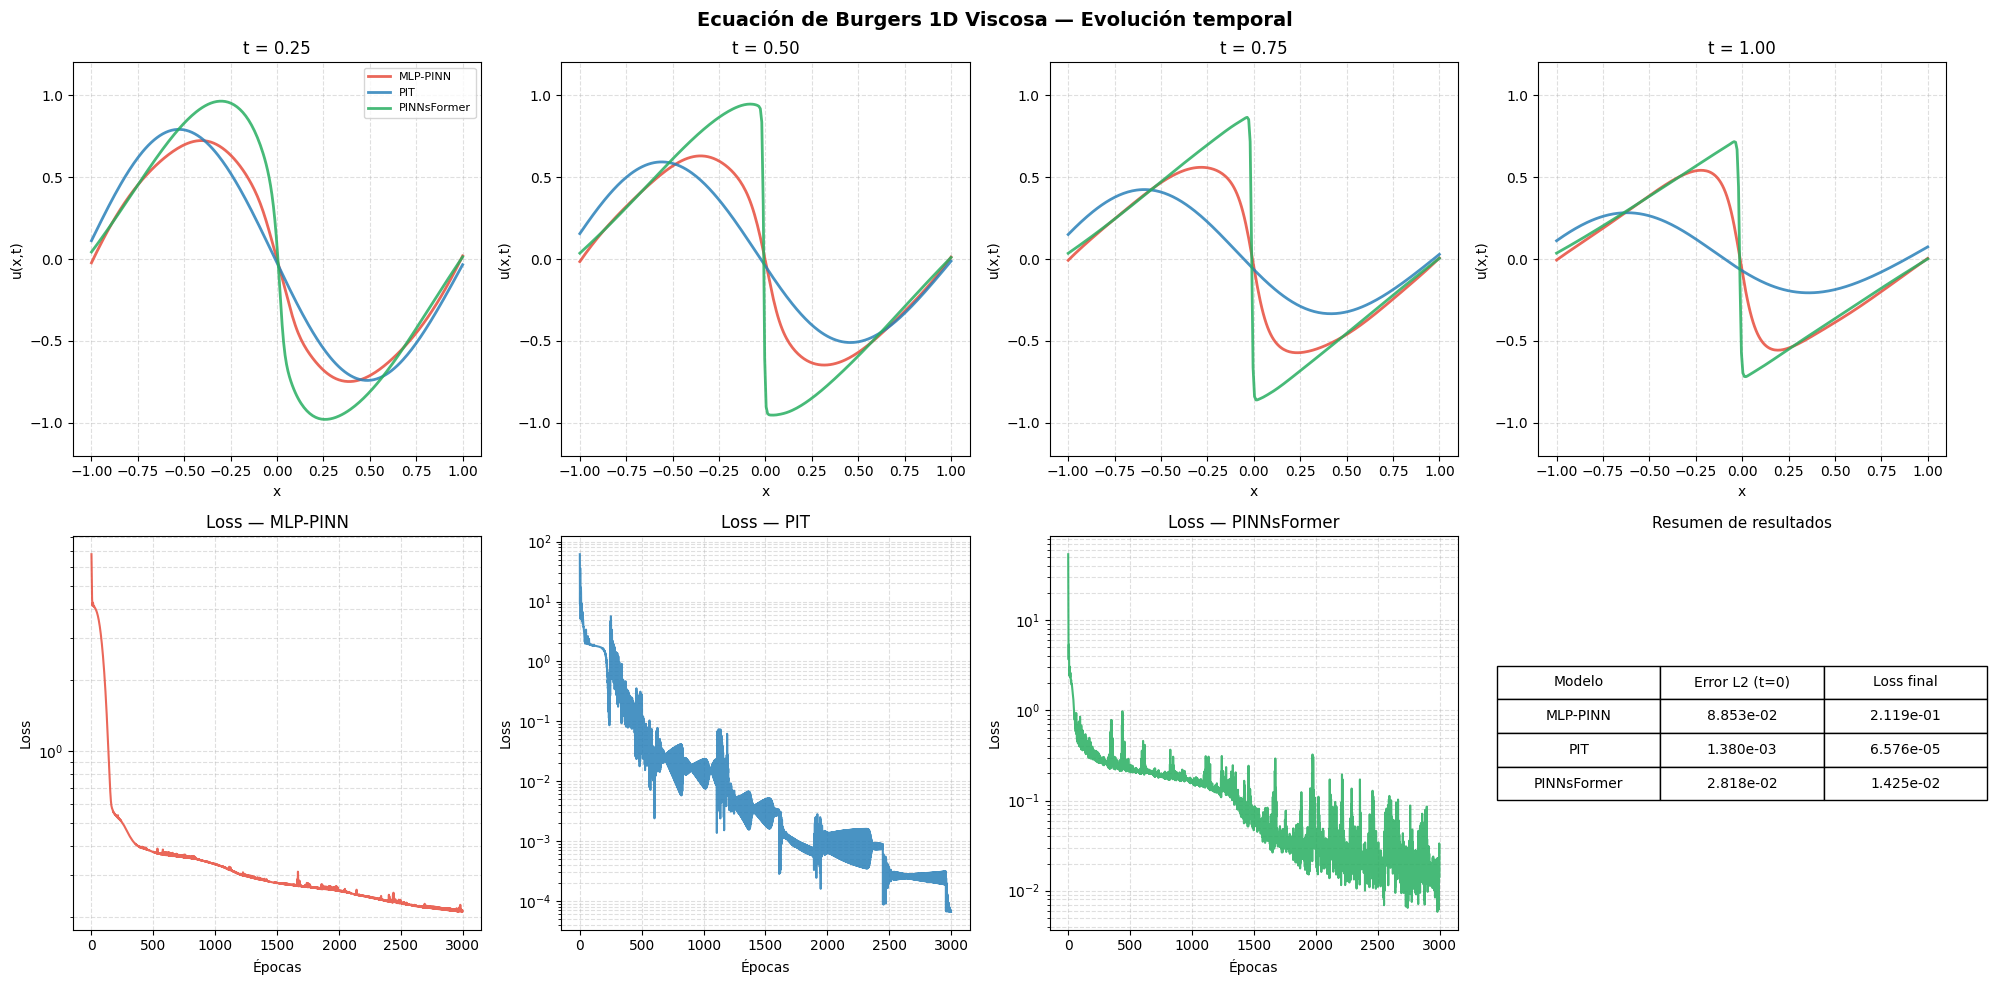

In [ ]:
# ── Evaluación: evolución temporal de la solución ─────────────────────────────
t_snapshots = [0.25, 0.50, 0.75, 1.00]
x_np = x_eval.cpu().numpy().flatten()

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Ecuación de Burgers 1D Viscosa — Evolución temporal', fontsize=14, fontweight='bold')
colors_b = {'MLP-PINN': '#e74c3c', 'PIT': '#2980b9', 'PINNsFormer': '#27ae60'}

# Fila 0: Predicciones en diferentes instantes de tiempo
for col, t_val in enumerate(t_snapshots):
    t_tensor = torch.full((N_eval, 1), t_val).to(device)
    xt_snap  = torch.cat([x_eval, t_tensor], dim=1)

    for name, model in [('MLP-PINN', mlp_b), ('PIT', pit_b), ('PINNsFormer', pf_b)]:
        model.eval()
        with torch.no_grad():
            u_snap = model(xt_snap).cpu().numpy().flatten()
        axs[0, col].plot(x_np, u_snap, color=colors_b[name], lw=2, alpha=0.85, label=name)

    axs[0, col].set(title=f't = {t_val:.2f}', xlabel='x', ylabel='u(x,t)')
    axs[0, col].set_ylim(-1.2, 1.2)
    axs[0, col].grid(True, ls='--', alpha=0.4)
    if col == 0:
        axs[0, col].legend(fontsize=8)

# Fila 1: Historiales de entrenamiento y tabla de errores de IC
for col, (name, hist, color) in enumerate([
    ('MLP-PINN',    hist_mlp_b, '#e74c3c'),
    ('PIT',         hist_pit_b, '#2980b9'),
    ('PINNsFormer', hist_pf_b,  '#27ae60'),
]):
    axs[1, col].semilogy(hist, color=color, lw=1.5, alpha=0.85)
    axs[1, col].set(title=f'Loss — {name}', xlabel='Épocas', ylabel='Loss')
    axs[1, col].grid(True, which='both', ls='--', alpha=0.4)

# Panel derecho inferior: tabla comparativa de la condición inicial
axs[1, 3].axis('off')
t0_tensor  = torch.zeros(N_eval, 1).to(device)
xt_t0      = torch.cat([x_eval, t0_tensor], dim=1)
u_ic_exact = -torch.sin(np.pi * x_eval).cpu().numpy().flatten()

tabla_data = [['Modelo', 'Error L2 (t=0)', 'Loss final']]
for name, model, hist in [
    ('MLP-PINN',    mlp_b, hist_mlp_b),
    ('PIT',         pit_b, hist_pit_b),
    ('PINNsFormer', pf_b,  hist_pf_b),
]:
    model.eval()
    with torch.no_grad():
        u_t0 = model(xt_t0).cpu().numpy().flatten()
    err = compute_l2_error(u_t0, u_ic_exact)
    tabla_data.append([name, f'{err:.3e}', f'{hist[-1]:.3e}'])

table = axs[1, 3].table(
    cellText=tabla_data[1:], colLabels=tabla_data[0],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False); table.set_fontsize(10)
table.scale(1.2, 1.8)
axs[1, 3].set_title('Resumen de resultados', fontsize=11)

plt.tight_layout(); plt.show()

## Análisis del Experimento 3
El tercer experimento aborda la ecuación viscosa de Burgers 1D, modelando un sistema dinámico espacio-temporal con un término advectivo fuertemente no lineal ($u \frac{\partial u}{\partial x}$). Este término provoca la formación de un frente de choque pronunciado. Bajo un entrenamiento estándar (optimizador Adam, 3000 épocas, arquitecturas base sin incrustaciones espaciales forzadas), los resultados revelan un fenómeno importante en la investigación de PINNs: **la divergencia entre la optimización matemática y la fidelidad física**.

Aunque el Perceptrón Multicapa (MLP) captura de forma visual y cualitativa mucho mejor la dinámica del choque en $t = 0.50$ y $t = 0.75$, su función de pérdida (Loss) final resulta ser numéricamente superior a la de la arquitectura *Physics-Informed Transformer (PIT)*. Este comportamiento paradójico podría ser por los siguientes factores topológicos y numéricos:

### 1. Viscosidad Artificial del Transformer
El mecanismo central del PIT (Self-Attention) procesa las coordenadas de colocación calculando similitudes y promediando vectores de estado. En un medio continuo, este promediado global actúa intrínsecamente como un **filtro de suavizado espacial**. Cuando el PIT se enfrenta a la formación del choque abrupto, descubre que difuminar la onda reduce drásticamente la magnitud de los gradientes espaciales ($\frac{\partial u}{\partial x}$). Al colapsar los gradientes, el residuo no lineal de la EDP se minimiza rápidamente. El Transformer logra una *loss* inferior porque optimiza hacia una solución matemáticamente "barata" pero físicamente incorrecta, introduciendo una *viscosidad numérica o artificial* masiva que destruye la onda.

### 2. La Rigidez del Choque y la Penalización del MLP
Por el contrario, el sesgo inductivo del MLP (procesamiento de coordenadas estrictamente independiente y punto a punto) le permite mantener representaciones afiladas. Al intentar ajustar un gradiente casi vertical en la zona del choque, las derivadas de segundo orden ($\nu \frac{\partial^2 u}{\partial x^2}$) explotan en magnitud. En este régimen de alta rigidez (*stiffness*), cualquier desalineamiento microscópico entre la predicción y la posición exacta del choque resulta en un castigo severo en el residuo de la EDP. La *loss* del MLP es mayor precisamente porque está intentando resolver la dinámica en su forma más compleja y escarpada, en lugar de evadirla.

### 3. Ruptura de la Causalidad Temporal
En este experimento 2D, las coordenadas espaciales y temporales $(x, t)$ se introducen simultáneamente en las arquitecturas. Para los Transformers (PIT y PINNsFormer), esto implica que el mecanismo de atención es bidireccional no solo en el espacio, sino también en el tiempo. Matemáticamente, el estado de un punto en $t = 0.2$ está siendo influenciado por la información de puntos en $t = 0.9$. Esta violación de la flecha del tiempo (fuga de información del futuro hacia el pasado) entorpece severamente la propagación del frente de onda advectivo, explicando el rendimiento pobre y deformado del PINNsFormer frente a la secuencialidad implícita que logra el MLP al no cruzar información temporal entre puntos durante la propagación hacia adelante.

**Conclusión:** En la resolución de EDPs dinámicas con formación de choques, una *loss* global más baja no garantiza una mejor representación física si la topología de la red favorece el suavizado excesivo. Las arquitecturas basadas en atención global penalizan la formación de discontinuidades y violan la causalidad temporal salvo que se implementen mecanismos de enmascaramiento estricto, demostrando nuevamente que el MLP base es un interpolador físico más robusto en regímenes no lineales de baja dimensionalidad.